# North San Andreas fault M7.6 Scenario

## 1. Setup

In [1]:
import os, json, shutil
from pathlib import Path
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import base64
from IPython.display import HTML

EVENT = 'bssc2014nsanandreassapsassha_m7p6_se'
os.environ['EVENT'] = EVENT

EVENT_DIR = Path.home() / 'shakemap_profiles/default/data' / EVENT / 'current'
PRODUCTS  = EVENT_DIR / 'products'
GF_OUT    = Path.home() / 'gf_output' / EVENT
CA_DATA   = Path('/workspaces/shakemap-gf-workshop/data/california_inputs')
PAGER_DIR = Path('/workspaces/shakemap-gf-workshop/data/pager/json/cali')
PAGER_PNG = Path('/workspaces/shakemap-gf-workshop/data/pager/onepager.png')

Note: expect the "shake -v" command to take about 1 minute.

In [2]:
%%bash
shake -v

ShakeMap version 0.1.dev1+g683bff506


---

# SHAKEMAP

---

## 2. Run ShakeMap

ShakeMap combines three types of input to estimate ground shaking:
- **Earthquake origin** — location, magnitude, depth, and fault geometry (`event.xml` + `rupture.json`)
- **Ground motion models (GMMs)** — equations that predict shaking from earthquakes
- **Site conditions (Vs30)** — local geology that amplifies or de-amplifies shaking (soft soils shake more than rock)

Four modules run in sequence:
- **`assemble`** — collect and validate all inputs
- **`model`** — compute ground motion at every grid point (computationally intense; about 1 minute to finish)
- **`contour`** — generate MMI shaking contour lines
- **`mapping`** — render map images (can take 30-45s)
- **`gridxml`** — export the grid file needed for ground failure models

Please be patient as it may take 1-2 minutes to run.

In [3]:
%%bash
shake $EVENT assemble -c 'demo' model contour mapping gridxml

INFO -- 2026-08-24 18:07:18 -- shake.main -- Running command assemble
INFO -- 2026-08-24 18:07:19 -- shake.main -- Finished running command assemble: Elapsed 0.67 secs
INFO -- 2026-08-24 18:07:19 -- shake.main -- Running command model
INFO -- 2026-08-24 18:07:19 -- model._threading_context -- BLAS thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-24 18:07:19 -- model._threading_context -- OpenMP thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-24 18:07:19 -- output_grid._adjust_resolution -- Resolution units specified in km, converting to degrees.
INFO -- 2026-08-24 18:07:19 -- output_grid._adjust_resolution -- Updated dx: 0.0169922 (degrees)
INFO -- 2026-08-24 18:07:19 -- output_grid._adjust_resolution -- Updated dy: 0.0134898 (degrees)
INFO -- 2026-08-24 18:07:54 -- shake.main -- Finished running command model: Elapsed 34.99 secs
INFO -- 2026-08-24 18:07:54 -- shake.main -- Running command contour
INFO -- 2026-08-24 18:07:56 -- shake.main 

## 3. ShakeMap maps

We will plot the **Modified Mercalli Intensity (MMI)** map — which
describes felt shaking in human terms — and the **Peak Ground Acceleration (PGA)**
map, which is used in engineering design.

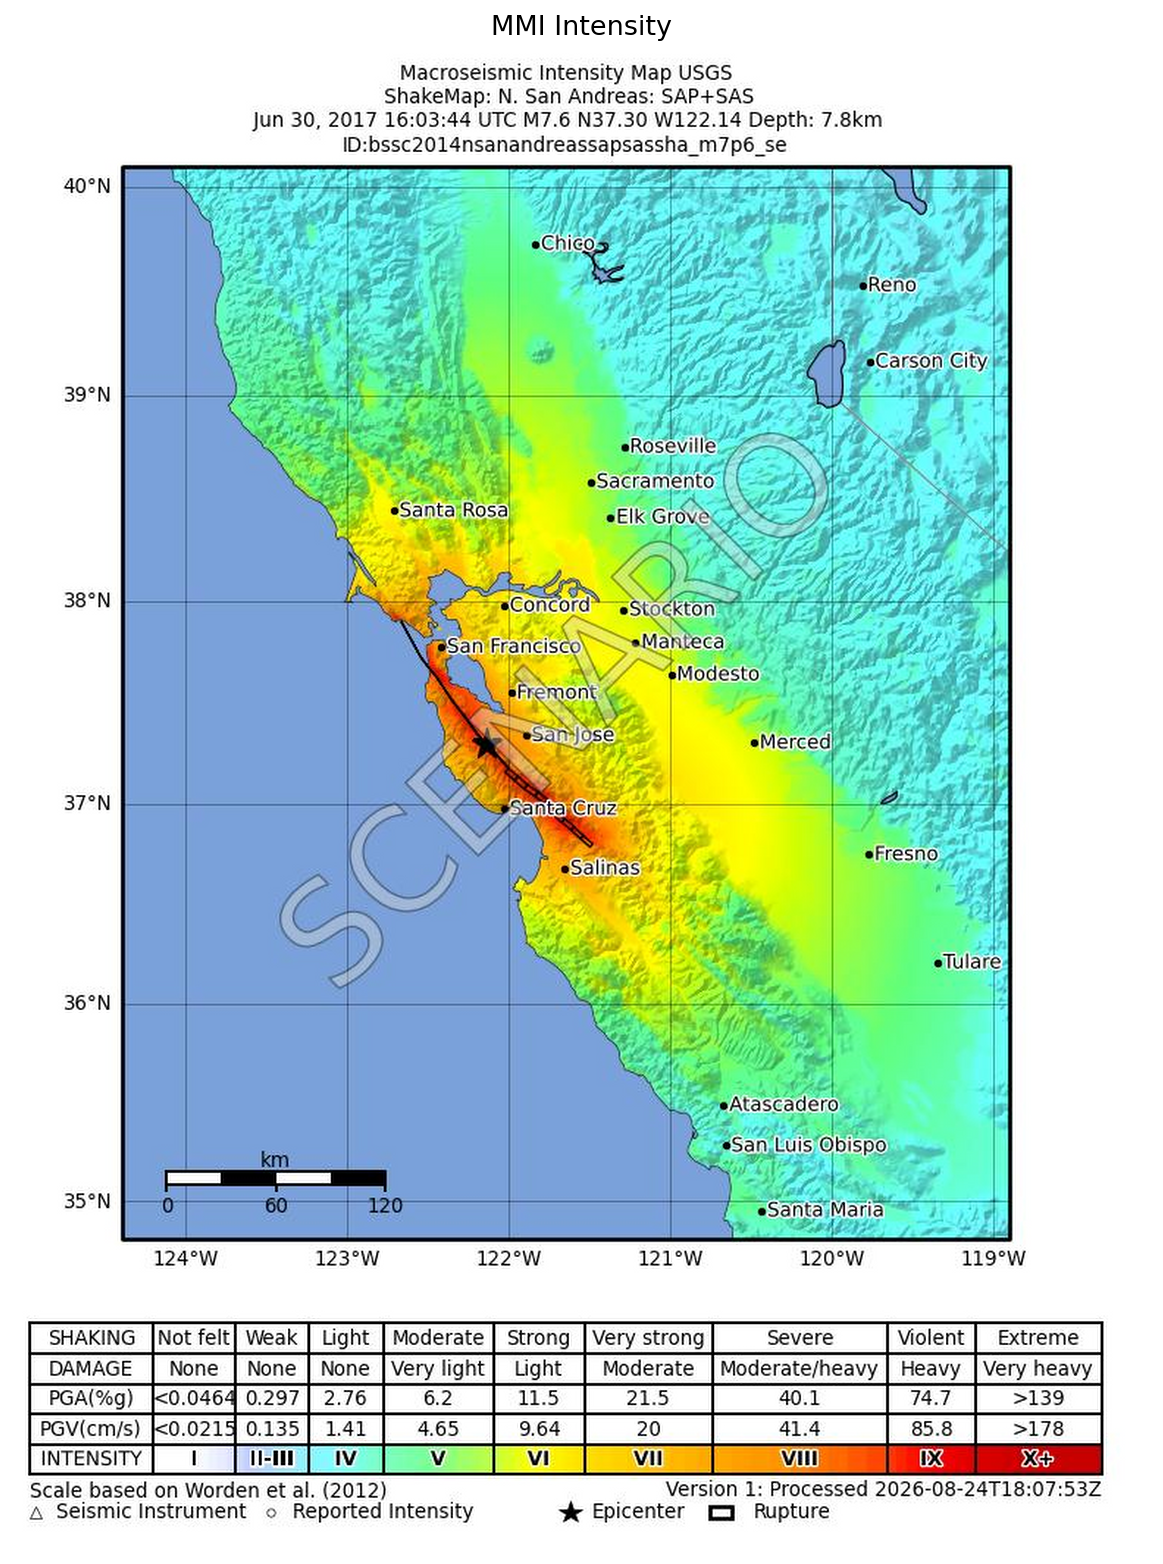

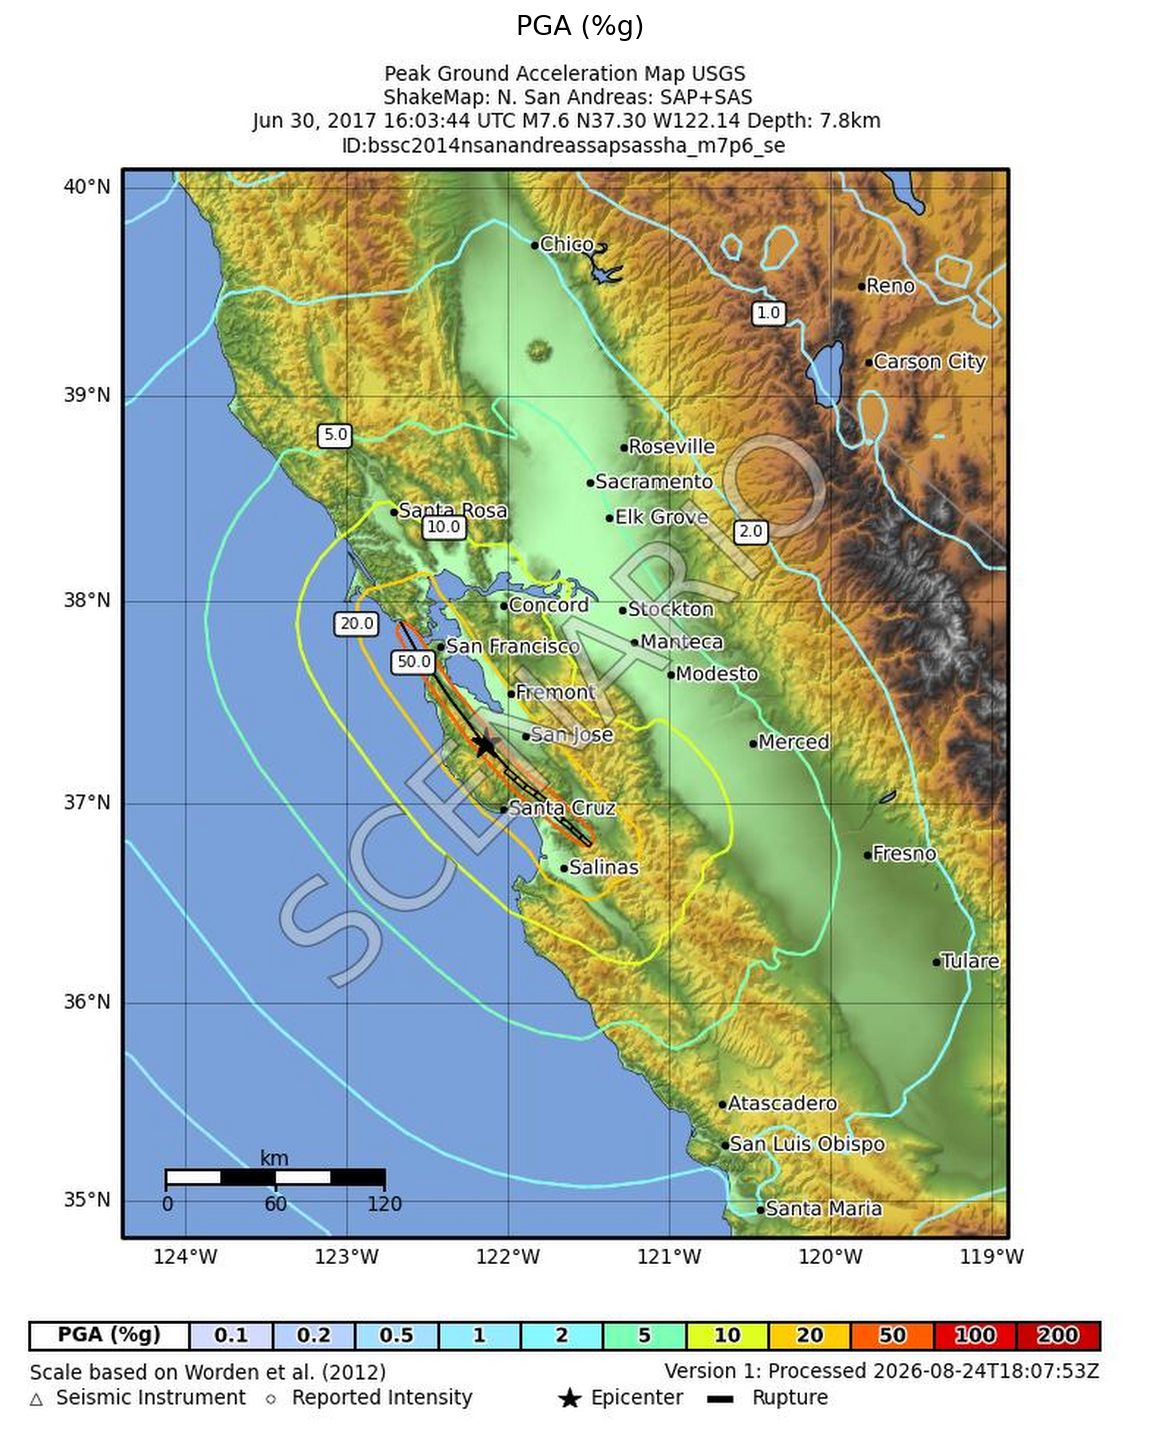

PosixPath('/home/vscode/san_andreas_ff_intensity.jpg')

In [4]:
for name, title in [('intensity.jpg', 'MMI Intensity'), ('pga.jpg', 'PGA (%g)')]:
    img = mpimg.imread(str(PRODUCTS / name))
    h, w = img.shape[:2]
    fig, ax = plt.subplots(figsize=(w/100, h/100), dpi=150)
    ax.imshow(img, interpolation='lanczos')
    ax.set_title(title, fontsize=13)
    ax.axis('off')
    plt.tight_layout(pad=0)
    plt.show()

shutil.copy(PRODUCTS / 'intensity.jpg',
            Path.home() / 'san_andreas_ff_intensity.jpg')

shutil.copy(PRODUCTS / 'intensity.jpg',
            Path.home() / 'san_andreas_ff_intensity.jpg')

---

# PAGER - Loss estimates

---

PAGER estimates fatalities and economic losses using ShakeMap grids combined with
with population data and country-level vulnerability models.

### Population exposure

`exposures.json` contains the number of people estimated to experience
each MMI level, based on LandScan population data and the ShakeMap grid.

In [5]:
with open(PAGER_DIR / 'exposures.json') as f:
    exposures = json.load(f)

exp = exposures['population_exposure']
labels = ['Not felt','Not felt','Weak','Light','Moderate',
          'Strong','Very Strong','Severe','Violent','Extreme']
print(f'{"MMI":<6} {"Population":>15}   Shaking')
print('-' * 42)
for mmi, pop, label in zip(exp['mmi'], exp['aggregated_exposure'], labels):
    if pop > 0:
        print(f'{mmi:<6} {pop:>15,}   {label}')

MMI         Population   Shaking
------------------------------------------
3               34,919   Weak
4           12,832,476   Light
5            4,176,074   Moderate
6            3,907,068   Strong
7            2,742,489   Very Strong
8            3,021,674   Severe
9              403,638   Violent


### Fatality estimate and alert level

`alerts.json` contains the fatality probability distribution.

In [6]:
with open(PAGER_DIR / 'alerts.json') as f:
    alerts = json.load(f)

fat = alerts['fatality']
print(f'Alert level: {fat["level"].upper()}')
print()
print(f'{"Fatalities":<20} {"Probability":>12}   Color')
print('-' * 45)
for b in fat['bins']:
    label = f'{b["min"]}–{b["max"]}'
    print(f'{label:<20} {b["probability"]*100:>11.1f}%   {b["color"]}')

Alert level: YELLOW

Fatalities            Probability   Color
---------------------------------------------
0–1                          0.4%   green
1–10                        14.4%   yellow
10–100                      57.2%   yellow
100–1000                    26.7%   orange
1000–10000                   1.4%   red
10000–100000                 0.0%   red
100000–10000000              0.0%   red


The onePAGER report is generated primarily from the JSON files examined above,
which contain the loss estimates, population exposure, and alert levels.
The map and intensity inset are generated separately from the ShakeMap grid.

Note the separate alerts: California has earthquake-resistant construction
(yellow fatalities) but extremely high property values (red economic losses).

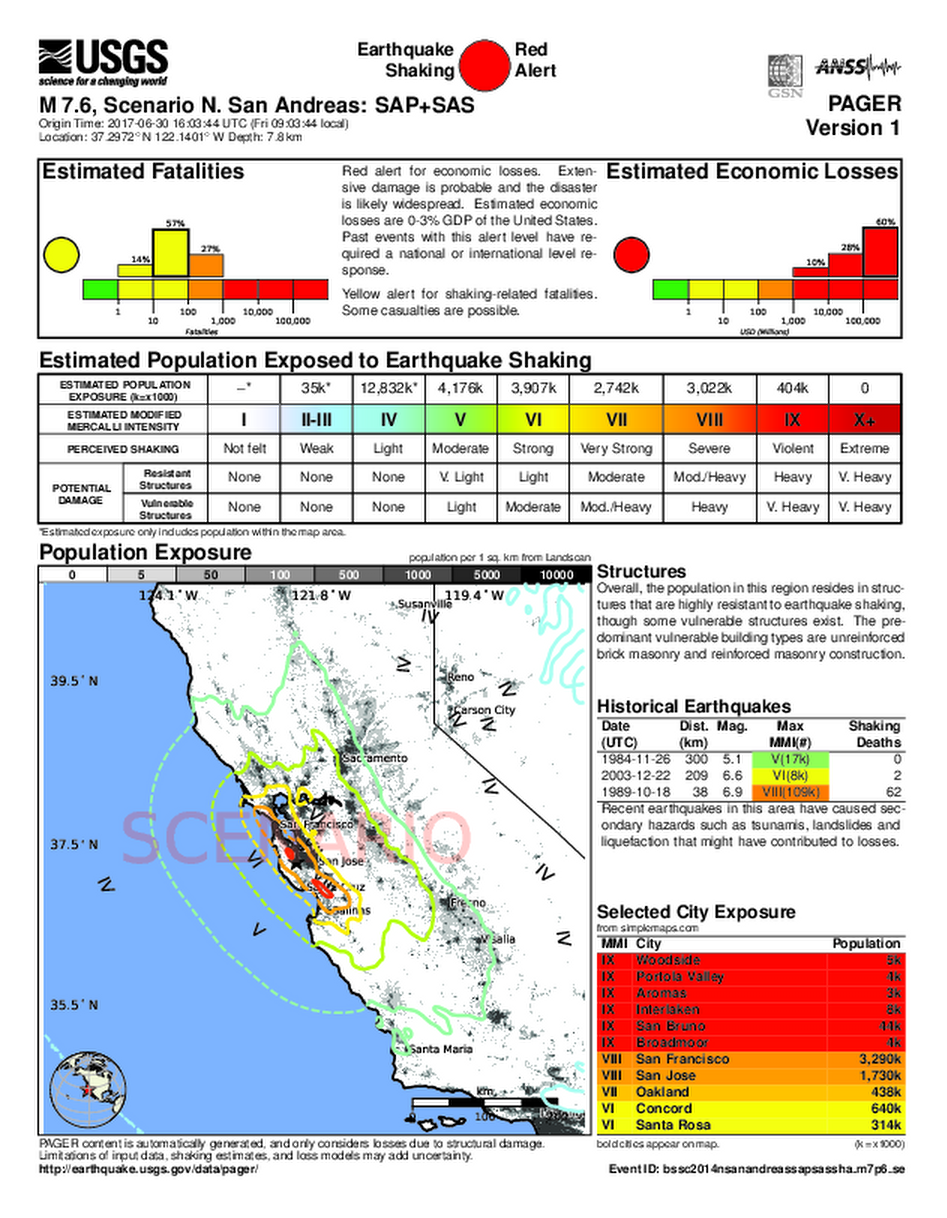

In [7]:
img = mpimg.imread(str(PAGER_PNG))
h, w = img.shape[:2]
fig, ax = plt.subplots(figsize=(w/100, h/100), dpi=150)
ax.imshow(img, interpolation='lanczos')
ax.axis('off')
plt.tight_layout(pad=0)
plt.show()

---

# GROUND FAILURE

---

## 5. Ground failure

Ground failure models estimate secondary hazards triggered by the shaking:
- **Landslide probability** — Nowicki Jessee et al. (2018): uses slope, PGV, and susceptibility
- **Liquefaction probability** — Zhu et al. (2017): uses Vs30, distance to water, and precipitation

The Santa Cruz Mountains produce high landslide hazard; Bay mud deposits
along the bay margins produce high liquefaction hazard.

Note These models run in the `gf` conda environment — we call them by their full
path so we don't need to switch environments mid-notebook.

In [9]:
%%bash
export EVENT=bssc2014nsanandreassapsassha_m7p6_se
/opt/conda/envs/gf/bin/gfailbin \
  /workspaces/shakemap-gf-workshop/data/gf_configs_ca.txt \
  ~/shakemap_profiles/default/data/$EVENT/current/products/grid.xml \
  --gis -w \
  -d /workspaces/shakemap-gf-workshop/data/california_inputs \
  -pf /workspaces/shakemap-gf-workshop/data/california_inputs/cali_GHS_POP_E2025.tif


Running the following models:
	jessee_2018_slim
	zhu_2017_general_slim
Applying bounds of lonmin -124.40, lonmax -118.89, latmin 34.79, latmax 40.10
Unable to determine source type, unknown if finite fault or point source

Now running jessee_2018_slim:

Now running zhu_2017_general_slim:
No uncertainty provided, filling with zeros
No uncertainty provided, filling with zeros

Files created:

/home/vscode/gf_output/bssc2014nsanandreassapsassha_m7p6_se/shakefile.txt
bssc2014nsanandreassapsassha_m7p6_se_jessee_2018_slim.hdf5
/home/vscode/gf_output/bssc2014nsanandreassapsassha_m7p6_se/bssc2014nsanandreassapsassha_m7p6_se_jessee_2018_slim_model.tif
/home/vscode/gf_output/bssc2014nsanandreassapsassha_m7p6_se/bssc2014nsanandreassapsassha_m7p6_se_jessee_2018_slim_model.kmz
bssc2014nsanandreassapsassha_m7p6_se_zhu_2017_general_slim.hdf5
/home/vscode/gf_output/bssc2014nsanandreassapsassha_m7p6_se/bssc2014nsanandreassapsassha_m7p6_se_zhu_2017_general_slim_model.tif
/home/vscode/gf_output/bssc2014

## 6. Interactive ground failure map

The map below shows landslide (left) and liquefaction (right) probability
side by side, with shaking contours overlaid.

In [11]:
%%bash
export EVENT=bssc2014nsanandreassapsassha_m7p6_se
/opt/conda/envs/gf/bin/python ~/plot_gf_interactive.py \
  --model "Jessee2018:$HOME/gf_output/$EVENT/${EVENT}_jessee_2018_slim_model.tif:$HOME/groundfailure/defaultconfigfiles/models/jessee_2018_slim.ini" \
  --model "Zhu2017:$HOME/gf_output/$EVENT/${EVENT}_zhu_2017_general_slim_model.tif:$HOME/groundfailure/defaultconfigfiles/models/zhu_2017_general_slim.ini" \
  --shakefile ~/shakemap_profiles/default/data/$EVENT/current/products/grid.xml \
  --contours  ~/shakemap_profiles/default/data/$EVENT/current/products/cont_mmi.json \
  --infojson  ~/gf_output/$EVENT/info.json \
  --outfile ~/san_andreas_gf.html

Reading /home/vscode/gf_output/bssc2014nsanandreassapsassha_m7p6_se/bssc2014nsanandreassapsassha_m7p6_se_jessee_2018_slim_model.tif...
Reading /home/vscode/gf_output/bssc2014nsanandreassapsassha_m7p6_se/bssc2014nsanandreassapsassha_m7p6_se_zhu_2017_general_slim_model.tif...
Saved: /home/vscode/san_andreas_gf.html
[Jessee2018] max P: 0.2372, area>0.002: 6.1%
[Zhu2017] max P: 0.4280, area>0.002: 35.5%


In [ ]:
html_path = Path.home() / 'san_andreas_gf.html'
b64 = base64.b64encode(html_path.read_bytes()).decode()
HTML(f'<iframe src="data:text/html;base64,{b64}" width="100%" height="600px"></iframe>')

---

End of Scenario Notebook